# Exercice pandas DataFrame avec le dataset Titanic

In [1]:
%matplotlib inline
# %matplotlib widget

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Exercice 1

  * Ouvrir le dataset Titanic avec le format excel.
  * explorer le dataset.


Sur kaggle voici les infos
https://www.kaggle.com/c/titanic/data

VARIABLE DESCRIPTIONS:
 * survival        Survival
                (0 = No; 1 = Yes)
 * pclass          Passenger Class
                (1 = 1st; 2 = 2nd; 3 = 3rd)
 * name            Name
 * sex             Sex
 * age             Age
 * sibsp           Number of Siblings/Spouses Aboard
 * parch           Number of Parents/Children Aboard
 * ticket          Ticket Number
 * fare            Passenger Fare
 * cabin           Cabin
 * embarked        Port of Embarkation (C = Cherbourg; Q = Queenstown; S = Southampton)

SPECIAL NOTES:
Pclass is a proxy for socio-economic status (SES)
 1st ~ Upper; 2nd ~ Middle; 3rd ~ Lower

Age is in Years; Fractional if Age less than One (1)
 If the Age is Estimated, it is in the form xx.5

With respect to the family relation variables (i.e. sibsp and parch)
some relations were ignored.  The following are the definitions used
for sibsp and parch.

Sibling:  Brother, Sister, Stepbrother, or Stepsister of Passenger Aboard Titanic
Spouse:   Husband or Wife of Passenger Aboard Titanic (Mistresses and Fiances Ignored)
Parent:   Mother or Father of Passenger Aboard Titanic
Child:    Son, Daughter, Stepson, or Stepdaughter of Passenger Aboard Titanic

Other family relatives excluded from this study include cousins,
nephews/nieces, aunts/uncles, and in-laws.  Some children travelled
only with a nanny, therefore parch=0 for them.  As well, some
travelled with very close friends or neighbors in a village, however,
the definitions do not support such relations.
 





# Solution 1

In [3]:
passenger = pd.read_excel('./data/dataset_titanic.xlsx')
passenger

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [4]:
passenger.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), object(1), str(4)
memory usage: 83.7+ KB


In [5]:
passenger.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [6]:
passenger.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Exercice 2

 * Faire un fichier excel avec un onglet / une feuille pour chaque classe.
 * Faire un autre fichier excel avec un onglet pour chaque port d'embarcation
 * Faire un fichier excel avec les passagers classés par âge.


# Solution 2

In [7]:
with pd.ExcelWriter('passenger_by_pclass.xlsx') as writer:
    passenger[passenger.Pclass == 1].to_excel(writer, sheet_name='class 1')
    passenger[passenger.Pclass == 2].to_excel(writer, sheet_name='class 2')
    passenger[passenger.Pclass == 3].to_excel(writer, sheet_name='class 3')



In [8]:
allpclass = [1, 2, 3]
with pd.ExcelWriter('passenger_by_pclass.xlsx') as writer:
    for pclass in allpclass:
        data = passenger[passenger['Pclass']==pclass]
        data.to_excel(writer, sheet_name='class {}'.format(pclass))


In [9]:
allembarked = passenger['Embarked'].unique()
print(allembarked)
with pd.ExcelWriter('passenger_by_embarked.xlsx') as writer:
    for embarked in allembarked:
        if type(embarked) == str:
            data = passenger[passenger.Embarked==embarked]
        else:
            data = passenger[passenger.Embarked.isnull()]        
        data.to_excel(writer, sheet_name=f'embarked {embarked}')


<StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str


In [10]:
ordered = passenger.sort_values(by='Age')
ordered.to_excel('passenger ordered.xlsx')
ordered.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
803,804,1,3,"Thomas, Master. Assad Alexander",male,0.42,0,1,2625,8.5167,NaN,C
755,756,1,2,"Hamalainen, Master. Viljo",male,0.67,1,1,250649,14.5000,NaN,S
644,645,1,3,"Baclini, Miss. Eugenie",female,0.75,2,1,2666,19.2583,NaN,C
469,470,1,3,"Baclini, Miss. Helene Barbara",female,0.75,2,1,2666,19.2583,NaN,C
78,79,1,2,"Caldwell, Master. Alden Gates",male,0.83,0,2,248738,29.0000,NaN,S


# Exercice 3

 * Sélectionner les passagers embarqués à **S** de la pclass **3**
 * Combien sont-ils ?
 * Faire la moyenne de leur âge/STD/median âge
 * Taux de survie.

# Solution 3

In [11]:
d = passenger[(passenger.Embarked=='S') & (passenger.Pclass==3)]
# d = passenger.loc[(passenger.Embarked=='S') & (passenger.Pclass==3), :]
# d = passenger.query('Embarked=="S" & Pclass==3')


print('count ', d['PassengerId'].count())
print('mean age ', d['Age'].mean())
print('std age ', d['Age'].std())
print('median age', d['Age'].median())
print('Survived rate', d['Survived'].mean())


count  353
mean age  25.69655172413793
std age  12.11090568500788
median age 25.0
Survived rate 0.18980169971671387


In [12]:
d = passenger.loc[(passenger.Embarked=='S') & (passenger.Pclass==3), :]
d.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,353.000000,353.000000,353.0,290.000000,353.000000,353.000000,353.000000
mean,440.685552,0.189802,3.0,25.696552,0.705382,0.439093,14.644083
std,263.352933,0.392701,0.0,12.110906,1.529408,0.954863,13.276609
min,1.000000,0.000000,3.0,1.000000,0.000000,0.000000,0.000000
25%,201.000000,0.000000,3.0,19.000000,0.000000,0.000000,7.854200
50%,432.000000,0.000000,3.0,25.000000,0.000000,0.000000,8.050000
75%,668.000000,0.000000,3.0,32.000000,1.000000,0.000000,16.100000
max,889.000000,1.000000,3.0,74.000000,8.000000,6.000000,69.550000


# Exercice 4

 * Calculer la moyenne des survies par classe
 * Faites une dissertation de gauche sur le taux de suivie en fonction de la classe.
   N'hésitez pas à cracher sur le grand capital.
 * Moyenne des survis par port d'embarcation
 * Moyenne des survis par (port d'embarcation X classe)
 * Sauvegarder tout ça sous excel


# Solution 4

In [13]:
by_pclass = passenger.groupby('Pclass')['Survived'].mean()
by_pclass

Pclass
1    0.629630
2    0.472826
3    0.242363
Name: Survived, dtype: float64

In [14]:
by_embarked = passenger.groupby('Embarked')['Survived'].mean()
by_embarked

Embarked
C    0.553571
Q    0.389610
S    0.336957
Name: Survived, dtype: float64

In [15]:
by_pclass_embarked = passenger.groupby(['Pclass', 'Embarked' ])['Survived'].mean()
by_pclass_embarked



Pclass  Embarked
1       C           0.694118
        Q           0.500000
        S           0.582677
2       C           0.529412
        Q           0.666667
        S           0.463415
3       C           0.378788
        Q           0.375000
        S           0.189802
Name: Survived, dtype: float64

<Axes: xlabel='Pclass,Embarked'>

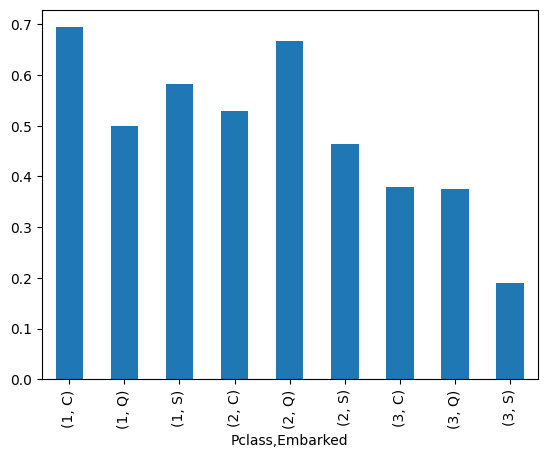

In [16]:
by_pclass_embarked.plot(kind='bar')

In [17]:
# with pd.ExcelWriter('passenger_survie.xlsx') as writer:
#     by_pclass.to_excel(writer, sheet_name='survie_by_pclass')
#     by_embarked.to_excel(writer, sheet_name='survie_by_embarked')
#     by_pclass_embarked.to_excel(writer, sheet_name='survie_by_pclass_embarked')

# Exercice 5

 * Créer une colonne *'age_decade'* pour les tranches d'age
 * Compter le nombre de passage par tranche d'age
 * Taux de survie par tranche d'age
 

# solution 5

In [18]:
passenger['age_decade'] = passenger['Age']//10
passenger['age_decade'] = pd.Categorical(passenger['age_decade'])
passenger.head()



,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,age_decade
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,2.0
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,3.0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,2.0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,3.0
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,3.0


In [19]:
passenger.groupby(['age_decade'])['PassengerId'].count()

age_decade
0.0     62
1.0    102
2.0    220
3.0    167
4.0     89
5.0     48
6.0     19
7.0      6
8.0      1
Name: PassengerId, dtype: int64

In [20]:
passenger.groupby('age_decade')['Survived'].mean()

age_decade
0.0    0.612903
1.0    0.401961
2.0    0.350000
3.0    0.437126
4.0    0.382022
5.0    0.416667
6.0    0.315789
7.0    0.000000
8.0    1.000000
Name: Survived, dtype: float64

<Axes: xlabel='age_decade'>

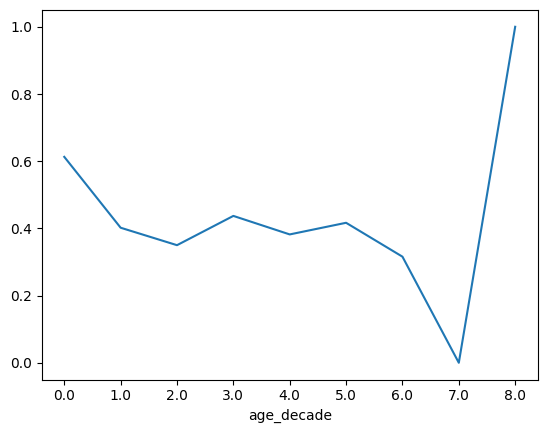

In [21]:
passenger.groupby('age_decade')['Survived'].mean().plot()


# Exercice 6

 * prix du ticket pour les survivants/non survivants

# Solution 6


In [22]:
passenger.groupby('Survived')['Fare'].mean()

Survived
0    22.117887
1    48.395408
Name: Fare, dtype: float64

# Exercice 7

 * demandez vous si la règle "les femmes et les enfants d'abord" a été respectée.

# Solution 7

In [23]:
passenger.groupby('Sex')['Survived'].mean()

Sex
female    0.742038
male      0.188908
Name: Survived, dtype: float64

In [24]:
print(passenger[passenger.Age>=16]['Survived'].mean())
print(passenger[passenger.Age<16]['Survived'].mean())

0.38193343898573695
0.5903614457831325


In [25]:
passenger['child'] = passenger.Age<16
passenger.groupby(['Sex', 'child'])['Survived'].mean()

Sex     child
female  False    0.756458
        True     0.651163
male    False    0.163873
        True     0.525000
Name: Survived, dtype: float64

# Exercice 8

 * Donnez le top 10 des prenoms pour les garçons.
 * Soyez mesquin et regardez si le prénom influence la survie.


# Solution 8

In [26]:
passenger['Name']

0                                Braund, Mr. Owen Harris
1      Cumings, Mrs. John Bradley (Florence Briggs Th...
2                                 Heikkinen, Miss. Laina
3           Futrelle, Mrs. Jacques Heath (Lily May Peel)
4                               Allen, Mr. William Henry
                             ...                        
886                                Montvila, Rev. Juozas
887                         Graham, Miss. Margaret Edith
888             Johnston, Miss. Catherine Helen "Carrie"
889                                Behr, Mr. Karl Howell
890                                  Dooley, Mr. Patrick
Name: Name, Length: 891, dtype: str

In [27]:
passenger['firstname'] = passenger['Name'].str.extract('(Mr\. |Don\. |Master\. |Rev\. |Col\.[A-Za-z ]*\()([A-Za-z]*)')[1]
df = passenger[passenger.Sex=='male']
df.groupby('firstname')['firstname'].count().sort_values(ascending=False).head(10)

<positron-console-cell-27>:1: SyntaxWarning: invalid escape sequence '\.'


firstname
William    34
John       23
George     14
Charles    13
Thomas     13
Henry      11
James      11
Richard    10
Johan       9
Karl        8
Name: firstname, dtype: int64

In [28]:
passenger.groupby(['firstname', 'Survived'])['firstname'].count().unstack('Survived').sort_values(by=0,ascending=False).head(15)

Survived,0,1
firstname,,
William,26.0,8.0
John,20.0,3.0
Thomas,11.0,2.0
James,10.0,1.0
Charles,10.0,3.0
George,10.0,4.0
Henry,9.0,2.0
Richard,8.0,2.0
Johan,8.0,1.0
